## Imports

In [17]:
import csv
import random
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import pickle
import numpy

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

## Import

In [18]:
better_soccer_data = []
with open('Preprocessed-Soccer-Dataset.csv', newline='', encoding='utf-8') as data:
    read = csv.reader(data)
    for xP in read:
        better_soccer_data.append(xP)

print('Rows loaded (including header):', len(better_soccer_data))
print('Columns:', len(better_soccer_data[0]))
print('Headers:', better_soccer_data[0])

Rows loaded (including header): 42527
Columns: 37
Headers: ['Home_L3_Pts', 'Home_L3_Goals', 'Home_L3_EnemyGoals', 'Home_L3_Wins', 'Home_L3_Losses', 'Home_L3_HomeWins', 'Home_L5_Pts', 'Home_L5_Goals', 'Home_L5_EnemyGoals', 'Home_L5_Wins', 'Home_L5_Losses', 'Home_L5_HomeWins', 'Home_L10_Pts', 'Home_L10_Goals', 'Home_L10_EnemyGoals', 'Home_L10_Wins', 'Home_L10_Losses', 'Home_L10_HomeWins', 'Away_L3_Pts', 'Away_L3_Goals', 'Away_L3_EnemyGoals', 'Away_L3_Wins', 'Away_L3_Losses', 'Away_L3_HomeWins', 'Away_L5_Pts', 'Away_L5_Goals', 'Away_L5_EnemyGoals', 'Away_L5_Wins', 'Away_L5_Losses', 'Away_L5_HomeWins', 'Away_L10_Pts', 'Away_L10_Goals', 'Away_L10_EnemyGoals', 'Away_L10_Wins', 'Away_L10_Losses', 'Away_L10_HomeWins', 'Target_Did_Home_Win']


## Data Split

In [19]:
data = better_soccer_data[1:]  # skip header row

eighty = int((len(data)) * 0.8)
training_set = data[:eighty]
testing_set  = data[eighty:]

training_labels = []
for r in training_set: training_labels.append(r.pop())
testing_labels = []
for r in testing_set: testing_labels.append(r.pop())

# Convert to numbers (float)
for i in range(len(training_set)):
    for j in range(len(training_set[i])):
        training_set[i][j] = float(training_set[i][j])

for i in range(len(testing_set)):
    for j in range(len(testing_set[i])):
        testing_set[i][j] = float(testing_set[i][j])

print('Training rows:', len(training_set))
print('Testing rows: ', len(testing_set))
print('Features per row:', len(training_set[0]))

Training rows: 34020
Testing rows:  8506
Features per row: 36


# 1st Model: Logistic Regression (Full Fat Version)

Logistic Regression is a good baseline and is generally decent for binary classification.

In [20]:
model = LogisticRegression()
model.fit(training_set, training_labels)

pickle.dump(model, open('finalized_model_M1.sav', 'wb'))
print('Model 1 saved: finalized_model_M1.sav')
print('Trained on', model.n_features_in_, 'features')

Model 1 saved: finalized_model_M1.sav
Trained on 36 features


## 2nd Model: Reduced Data Set (Top 24 Features)
L3 did worse than L5 or L10. Sustained performance over more games is a stronger predictor of match outcome than short-term form.

Features:
- Home: Last 5 games (index 6–11) and Last 10 games (index 12–17)
- Away: Last 5 games (index 24–29) and Last 10 games (index 30–35)

In [21]:
# Indices of the top features by Pearson correlation (L5 and L10 windows only)
INDEX4reduced = [6, 7, 8, 9, 10, 11,    # Home L5
                 12, 13, 14, 15, 16, 17, # Home L10
                 24, 25, 26, 27, 28, 29, # Away L5
                 30, 31, 32, 33, 34, 35] # Away L10

# Build reduced training and testing sets
training_setR = []
for r in training_set:
    rowR = []
    for i in INDEX4reduced:
        rowR.append(r[i])
    training_setR.append(rowR)

testing_setR = []
for r in testing_set:
    rowR = []
    for i in INDEX4reduced:
        rowR.append(r[i])
    testing_setR.append(rowR)


# 2nd Model: Logistic Regression (Skim Milk)

In [22]:

model2 = LogisticRegression()
model2.fit(training_setR, training_labels)

pickle.dump(model2, open('finalized_model_M2.sav', 'wb'))
print('Model 2 saved: finalized_model_M2.sav')
print('Trained on', model2.n_features_in_, 'features')

Model 2 saved: finalized_model_M2.sav
Trained on 24 features


## Model: KNN (Full Feature Set)

In [23]:
knn_full = KNeighborsClassifier(n_neighbors=15)
knn_full.fit(training_set, training_labels)
knn_score = knn_full.score(testing_set, testing_labels)
print(f'KNN(k=15): {round(knn_score * 100, 2)}%')

pickle.dump(knn_full, open('knn_full.sav', 'wb'))
print('KNN Model on Full Feature Set saved: knn_full.sav')
print('Trained on', knn_full.n_features_in_, 'features')

KNN(k=15): 57.02%
KNN Model on Full Feature Set saved: knn_full.sav
Trained on 36 features


## Model : Gaussian Naive Bayes (Full Feature Set)

In [24]:
naive_full = GaussianNB()
naive_full.fit(training_set, training_labels)
gb_score = naive_full.score(testing_set, testing_labels)
print(f'Gaussian Naive Bayes: {round(gb_score * 100, 2)}%')

pickle.dump(naive_full, open('naive_bayes_full.sav', 'wb'))
print('Gaussian Naive Bayes Model on Full Feature Set saved: naive_bayes_full.sav')
print('Trained on', naive_full.n_features_in_, 'features')

Gaussian Naive Bayes: 60.99%
Gaussian Naive Bayes Model on Full Feature Set saved: naive_bayes_full.sav
Trained on 36 features


## Model: Random Forest (Full Feature Set)

In [25]:
randomTrees = RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_split=5,random_state=101)
randomTrees.fit(training_set, training_labels)

resultTrees = randomTrees.score(testing_set, testing_labels)

pickle.dump(randomTrees, open('randomTrees.sav', 'wb'))
print("Random Forest (Full features) score: " + str(round(resultTrees * 100, 2)) + "%")
print(randomTrees.feature_importances_)

Random Forest (Full features) score: 61.62%
[0.01692272 0.02430865 0.02277149 0.00761815 0.00830706 0.00692223
 0.02811546 0.03602115 0.02687097 0.01308782 0.01338504 0.01015943
 0.07284673 0.0823365  0.04272446 0.04516077 0.03793968 0.01797395
 0.01652624 0.02831863 0.02420627 0.00812508 0.00838483 0.00762464
 0.02827255 0.03738139 0.02840558 0.01281984 0.01207055 0.00971144
 0.06095812 0.06886975 0.0446514  0.03664076 0.03555474 0.01800592]


## # Load Models from disk & print()

In [26]:
load1 = pickle.load(open('finalized_model_M1.sav', 'rb'))
load2 = pickle.load(open('finalized_model_M2.sav', 'rb'))

result1 = load1.score(testing_set, testing_labels)
result2 = load2.score(testing_setR, testing_labels)

print('Model 1 (Full features) score:    ' + str(round(result1 * 100, 2)) + '%')
print('Model 2 (Reduced features) score: ' + str(round(result2 * 100, 2)) + '%')
	# Looks like we get about 60% accuracy for both
	# This means it's learning something from the data, just not much XD

Model 1 (Full features) score:    62.16%
Model 2 (Reduced features) score: 62.12%


## Model: Descision Tree

In [27]:
dtree = DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=101)
dtree.fit(training_set, training_labels)

dtree_score = dtree.score(testing_set, testing_labels)
print(f'Decision Tree: {round(dtree_score * 100, 2)}%')

pickle.dump(dtree, open('decision_tree.sav', 'wb'))
print('Decision Tree saved: decision_tree.sav')
print('Trained on', dtree.n_features_in_, 'features')

Decision Tree: 61.13%
Decision Tree saved: decision_tree.sav
Trained on 36 features


# Evaluation and Analysis

In [28]:
pdf = PdfPages('model_evaluation.pdf')

## Sklearn Score

Logistic Regression score: 62.16%
KNN score (k=15): 57.02%
Gaussian Naive Bayes: 60.99%
Random Forest score: 61.62%
Decision Tree: 61.13%


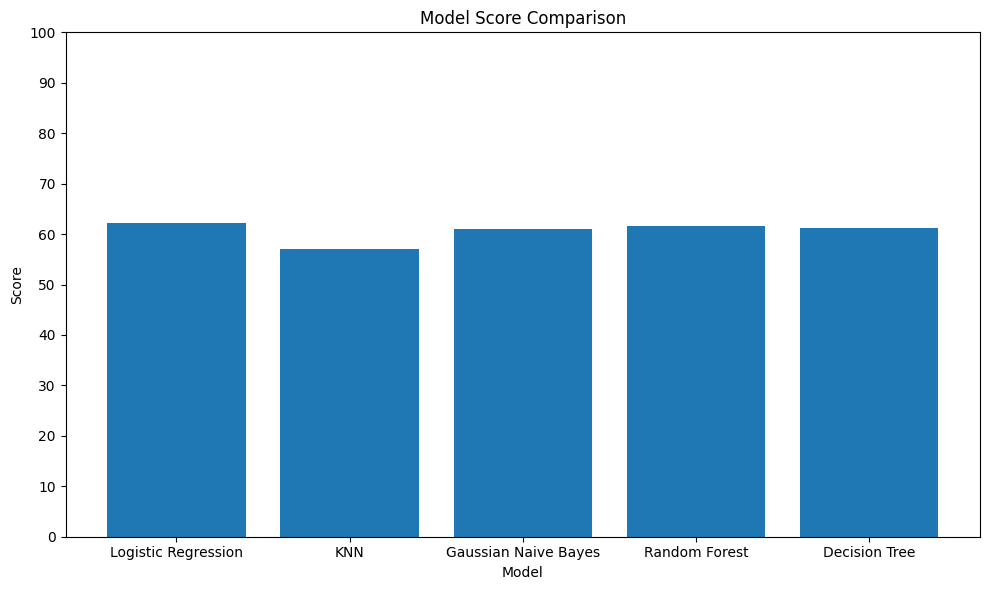

In [29]:
# The score for each of the ML techniques were calculated in cells above

print('Logistic Regression score: ' + str(round(result1 * 100, 2)) + '%')
print(f'KNN score (k=15): {round(knn_score * 100, 2)}%')
print(f'Gaussian Naive Bayes: {round(gb_score * 100, 2)}%')
print("Random Forest score: " + str(round(resultTrees * 100, 2)) + "%")
print(f'Decision Tree: {round(dtree_score * 100, 2)}%')

models = ['Logistic Regression', 'KNN', 'Gaussian Naive Bayes', 'Random Forest', 'Decision Tree']
scores = [result1, knn_score, gb_score, resultTrees, dtree_score]

scores = [s * 100 for s in scores]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, scores)


ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Score Comparison')
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))

fig.tight_layout()
pdf.savefig(fig)

## Classifiers Across Time Window Sizes

Logistic Regression | L3: 58.55%
Logistic Regression | L5: 60.26%
Logistic Regression | L10: 61.99%
KNN | L3: 53.93%
KNN | L5: 55.98%
KNN | L10: 57.95%
Naive Bayes | L3: 58.42%
Naive Bayes | L5: 59.63%
Naive Bayes | L10: 61.3%
Decision Tree | L3: 57.47%
Decision Tree | L5: 59.6%
Decision Tree | L10: 61.15%
Random Forest | L3: 57.45%
Random Forest | L5: 60.42%
Random Forest | L10: 61.87%


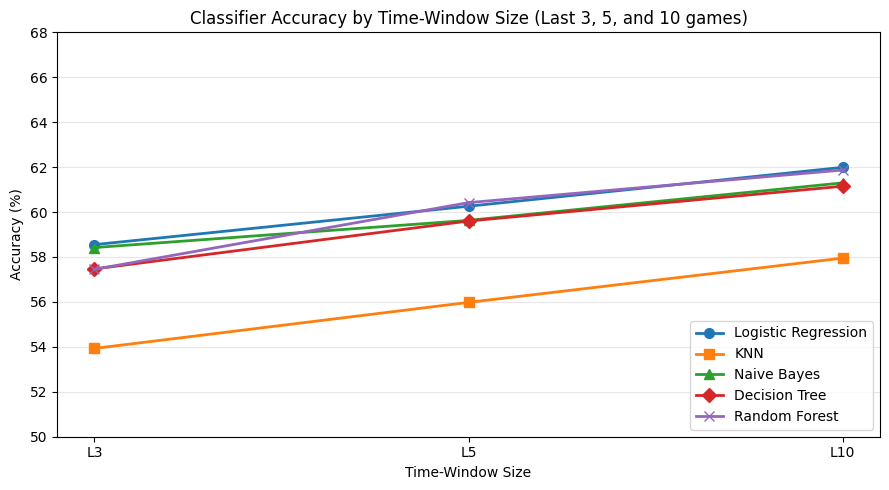

In [30]:
INDEX_L3  = [0,1,2,3,4,5,   18,19,20,21,22,23]
INDEX_L5  = [6,7,8,9,10,11,  24,25,26,27,28,29]
INDEX_L10 = [12,13,14,15,16,17, 30,31,32,33,34,35]

def make_subset(dataset, indices):
    return [[row[i] for i in indices] for row in dataset]

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN':                 KNeighborsClassifier(n_neighbors=15),
    'Naive Bayes':         GaussianNB(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, min_samples_split=5, random_state=101),
    'Random Forest':       RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_split=5, random_state=101),
}

windows = {'L3': INDEX_L3, 'L5': INDEX_L5, 'L10': INDEX_L10}

scores = {clf_name: [] for clf_name in classifiers}

for clf_name, clf in classifiers.items():
    for win_name, idx in windows.items():
        tr = make_subset(training_set, idx)
        te = make_subset(testing_set, idx)
        clf.fit(tr, training_labels)
        score = clf.score(te, testing_labels)
        scores[clf_name].append(round(score * 100, 2))
        print(f'{clf_name} | {win_name}: {round(score * 100, 2)}%')

# Plot
window_labels = ['L3', 'L5', 'L10']
markers = ['o', 's', '^', 'D', 'x']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(9, 5))

for (model, vals), marker, color in zip(scores.items(), markers, colors):
    ax.plot(window_labels, vals, marker=marker, color=color, label=model, linewidth=2, markersize=7)

ax.set_xlabel('Time-Window Size')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Classifier Accuracy by Time-Window Size (Last 3, 5, and 10 games)')
ax.legend(loc='lower right')
ax.set_ylim(50, 68)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
pdf.savefig(fig)
# plt.savefig('window_accuracy_linechart.png', dpi=150)
plt.show()

## Sklearn Confusion Matrix

In [32]:
# Logistic Regression
y_pred_lr = load1.predict(testing_set)
confusion_matrix_lr = confusion_matrix(testing_labels, y_pred_lr)

# KNN
y_pred_knn = knn_full.predict(testing_set)
confusion_matrix_knn = confusion_matrix(testing_labels, y_pred_knn)

# Gaussian Naive Bayes
y_pred_gnb = naive_full.predict(testing_set)
confusion_matrix_gnb = confusion_matrix(testing_labels, y_pred_gnb)

# Random Forest
y_pred_rf = randomTrees.predict(testing_set)
confusion_matrix_rf = confusion_matrix(testing_labels, y_pred_rf)

# Decision Tree
y_pred_dtree = dtree.predict(testing_set)
confusion_matrix_dtree = confusion_matrix(testing_labels, y_pred_dtree)

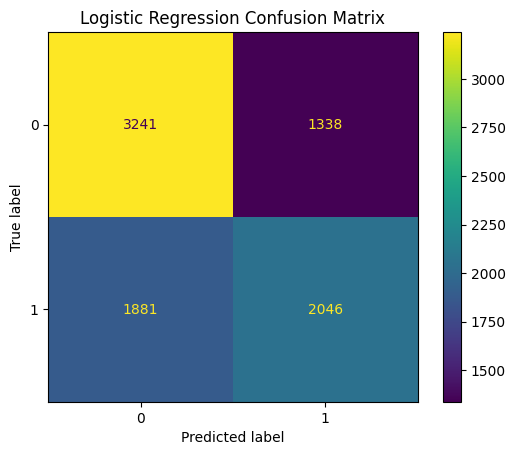

In [33]:
fig, combined_guy = plt.subplots()
# fig.savefig() if we want to use in our paper.

ConfusionMatrixDisplay(confusion_matrix_lr).plot(ax=combined_guy)
combined_guy.set_title('Logistic Regression Confusion Matrix')
plt.show()

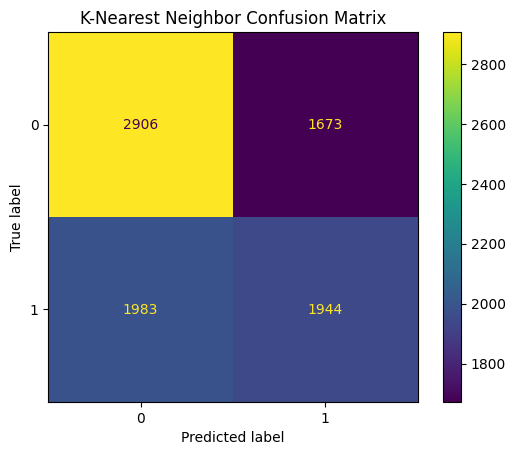

In [34]:
fig, combined_guy = plt.subplots()
# fig.savefig() if we want to use in our paper.

ConfusionMatrixDisplay(confusion_matrix_knn).plot(ax=combined_guy)
combined_guy.set_title('K-Nearest Neighbor Confusion Matrix')
plt.show()

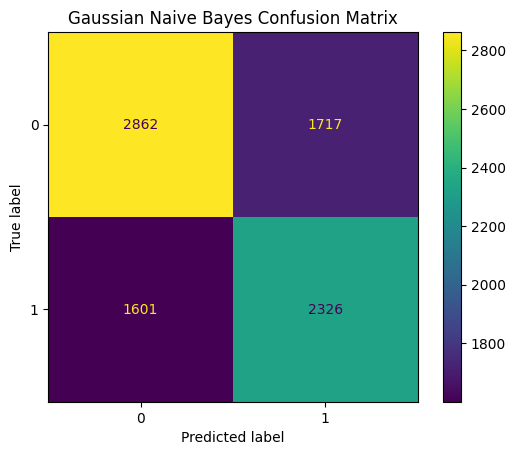

In [35]:
fig, combined_guy = plt.subplots()
# fig.savefig() if we want to use in our paper.

ConfusionMatrixDisplay(confusion_matrix_gnb).plot(ax=combined_guy)
combined_guy.set_title('Gaussian Naive Bayes Confusion Matrix')
plt.show()

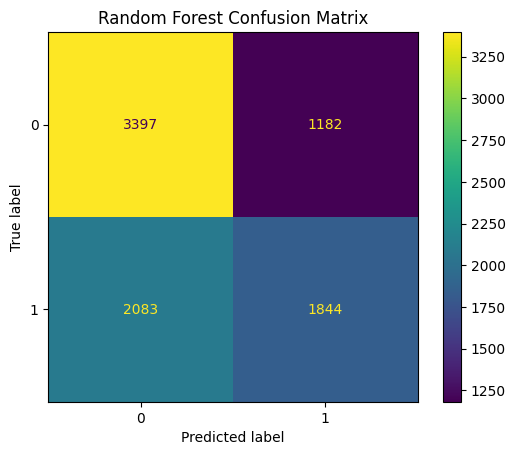

In [36]:
fig, combined_guy = plt.subplots()
# fig.savefig() if we want to use in our paper.

ConfusionMatrixDisplay(confusion_matrix_rf).plot(ax=combined_guy)
combined_guy.set_title('Random Forest Confusion Matrix')
plt.show()

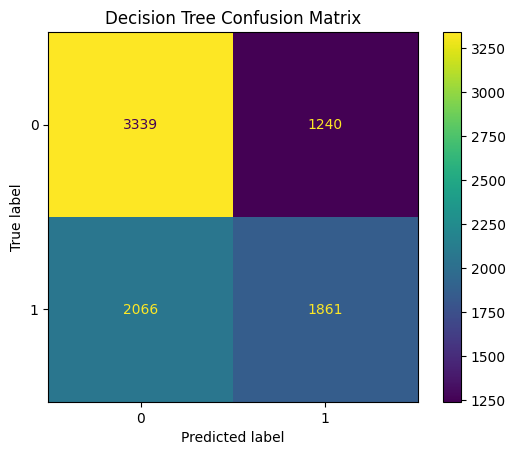

In [37]:
fig, combined_guy = plt.subplots()
# fig.savefig() if we want to use in our paper.

ConfusionMatrixDisplay(confusion_matrix_dtree).plot(ax=combined_guy)
combined_guy.set_title('Decision Tree Confusion Matrix')
plt.show()

## Classification Reports

In [38]:
# Classification Reports for all models
print("=========Logistic Regression")
print(classification_report(testing_labels, y_pred_lr))
print("\n")

print("=========KNN")
print(classification_report(testing_labels, y_pred_knn))
print("\n")

print("=========Gaussian Naive Bayes")
print(classification_report(testing_labels, y_pred_gnb))
print("\n")

print("=========Random Forest")
print(classification_report(testing_labels, y_pred_rf))
print("\n")

print("=========Decision Tree")
print(classification_report(testing_labels, y_pred_dtree))
print("\n")

=========Logistic Regression
              precision    recall  f1-score   support

           0       0.63      0.71      0.67      4579
           1       0.60      0.52      0.56      3927

    accuracy                           0.62      8506
   macro avg       0.62      0.61      0.61      8506
weighted avg       0.62      0.62      0.62      8506



=========KNN
              precision    recall  f1-score   support

           0       0.59      0.63      0.61      4579
           1       0.54      0.50      0.52      3927

    accuracy                           0.57      8506
   macro avg       0.57      0.56      0.56      8506
weighted avg       0.57      0.57      0.57      8506



=========Gaussian Naive Bayes
              precision    recall  f1-score   support

           0       0.64      0.63      0.63      4579
           1       0.58      0.59      0.58      3927

    accuracy                           0.61      8506
   macro avg       0.61      0.61      0.61      850

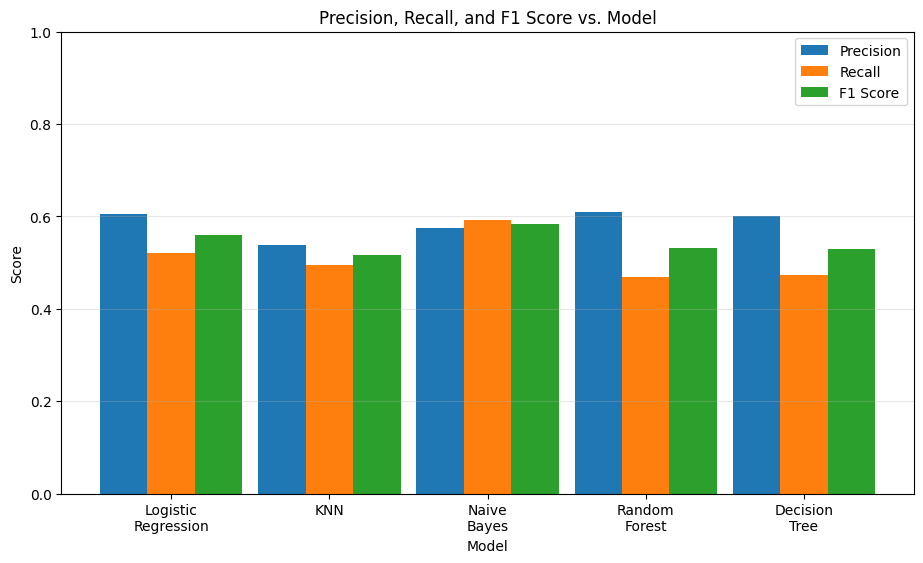

In [39]:
model_list = ['Logistic\nRegression', 'KNN', 'Naive\nBayes', 'Random\nForest', 'Decision\nTree']
y_list = [y_pred_lr, y_pred_knn, y_pred_gnb, y_pred_rf, y_pred_dtree] #"y is it named like that? "y pred" XD

precision = []
recall = []
f1 = []

for y in y_list:
    precision.append(precision_score(testing_labels, y, pos_label='1'))
    recall.append(recall_score(testing_labels, y, pos_label='1'))
    f1.append(f1_score(testing_labels, y, pos_label='1'))

xP = numpy.arange(len(model_list))
width = 0.3

fig, combined_guy = plt.subplots(figsize=(11, 6))
combined_guy.bar(xP - width, precision, width, label='Precision')
combined_guy.bar(xP, recall, width, label='Recall')
combined_guy.bar(xP + width, f1, width, label='F1 Score')

combined_guy.set_xlabel('Model')
combined_guy.set_ylabel('Score')
combined_guy.set_title('Precision, Recall, and F1 Score vs. Model')

combined_guy.legend()
combined_guy.grid(axis='y', alpha=0.3)

combined_guy.set_xticks(xP)
combined_guy.set_xticklabels(model_list)
combined_guy.set_ylim(0, 1)

pdf.savefig(fig)
plt.show()
pdf.close()